# NLP Text Classification Report

This notebook summarizes the text classification pipeline results: model comparison, prediction analysis, error analysis and dashboard-ready outputs.

Run it from the project root directory, after executing:

```bash
python -m src.run_pipeline
```

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

METRICS_PATH = Path('outputs/metrics/model_metrics.csv')
PREDICTIONS_PATH = Path('outputs/predictions/test_predictions.csv')
POWERBI_DIR = Path('outputs/powerbi')
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(METRICS_PATH)
preds = pd.read_csv(PREDICTIONS_PATH)

metrics

,model,accuracy,precision,recall,f1,roc_auc,best_cv_f1,best_params
0,random_forest,0.875,1.000000,0.75,0.857143,0.9375,NaN,NaN
1,xgboost,0.750,0.666667,1.00,0.800000,0.7500,NaN,NaN
2,logistic_regression,0.750,0.750000,0.75,0.750000,0.9375,NaN,NaN
3,linear_svm,0.750,0.750000,0.75,0.750000,0.9375,NaN,NaN
4,logistic_regression_tuned,0.750,0.750000,0.75,0.750000,0.9375,0.690476,"{'model__C': 2.0, 'tfidf__max_features': 1000,..."


## Model comparison

Models are compared using accuracy, precision, recall, F1 and ROC-AUC.

In [2]:
metrics_sorted = metrics.sort_values('f1', ascending=False).reset_index(drop=True)
best_model = metrics_sorted.loc[0, 'model']
metrics_sorted

,model,accuracy,precision,recall,f1,roc_auc,best_cv_f1,best_params
0,random_forest,0.875,1.000000,0.75,0.857143,0.9375,NaN,NaN
1,xgboost,0.750,0.666667,1.00,0.800000,0.7500,NaN,NaN
2,logistic_regression,0.750,0.750000,0.75,0.750000,0.9375,NaN,NaN
3,linear_svm,0.750,0.750000,0.75,0.750000,0.9375,NaN,NaN
4,logistic_regression_tuned,0.750,0.750000,0.75,0.750000,0.9375,0.690476,"{'model__C': 2.0, 'tfidf__max_features': 1000,..."


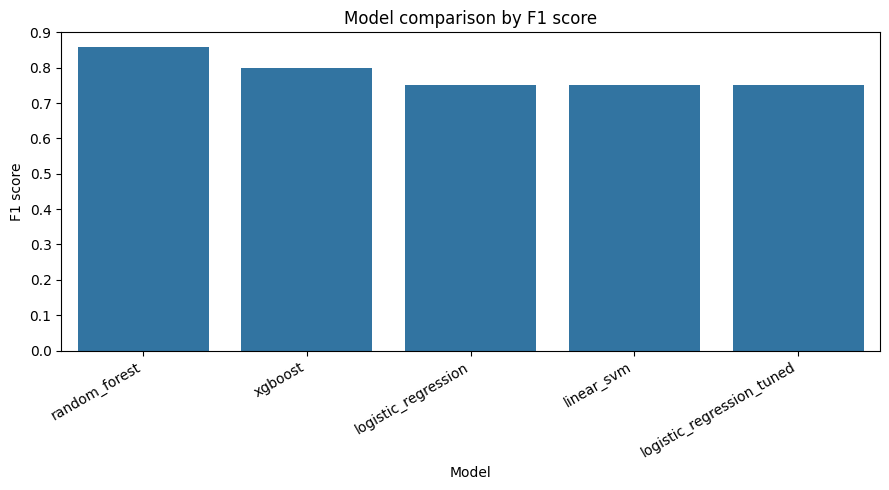

In [3]:
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_sorted, x='model', y='f1')
plt.xticks(rotation=30, ha='right')
plt.title('Model comparison by F1 score')
plt.xlabel('Model')
plt.ylabel('F1 score')
plt.tight_layout()
plt.show()

## Prediction analysis

The prediction export contains actual label, predicted label, confidence score and error type.

In [4]:
preds.head(10)

,text,actual,predicted,spam_probability,actual_label,predicted_label,is_correct,error_type
0,Could you please confirm the meeting agenda?,0,0,0.133333,ham,ham,True,correct
1,URGENT! Your account has been selected for a c...,1,1,0.646667,spam,spam,True,correct
2,Limited time offer! Get cheap loans instantly.,1,0,0.426667,spam,ham,False,false_negative
3,Thanks for your help yesterday.,0,0,0.453333,ham,ham,True,correct
4,Claim your free gift card today.,1,1,0.540000,spam,spam,True,correct
5,"I am running late, sorry.",0,0,0.380000,ham,ham,True,correct
6,See you at the office tomorrow.,0,0,0.153333,ham,ham,True,correct
7,Free entry in our weekly competition. Text WIN...,1,1,0.573333,spam,spam,True,correct


In [5]:
summary = pd.DataFrame({
    'metric': ['rows', 'correct_predictions', 'incorrect_predictions', 'accuracy_from_predictions'],
    'value': [
        len(preds),
        int(preds['is_correct'].sum()),
        int((~preds['is_correct']).sum()),
        float(preds['is_correct'].mean()),
    ]
})
summary

,metric,value
0,rows,8.000
1,correct_predictions,7.000
2,incorrect_predictions,1.000
3,accuracy_from_predictions,0.875


## Error analysis

In [6]:
error_counts = preds['error_type'].value_counts().reset_index()
error_counts.columns = ['error_type', 'count']
error_counts

,error_type,count
0,correct,7
1,false_negative,1


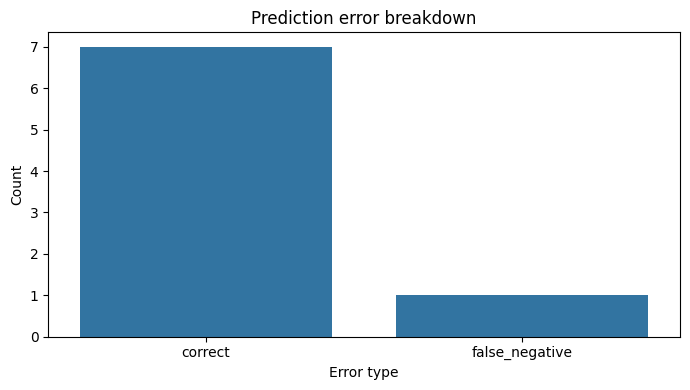

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=preds, x='error_type')
plt.title('Prediction error breakdown')
plt.xlabel('Error type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Prediction confidence

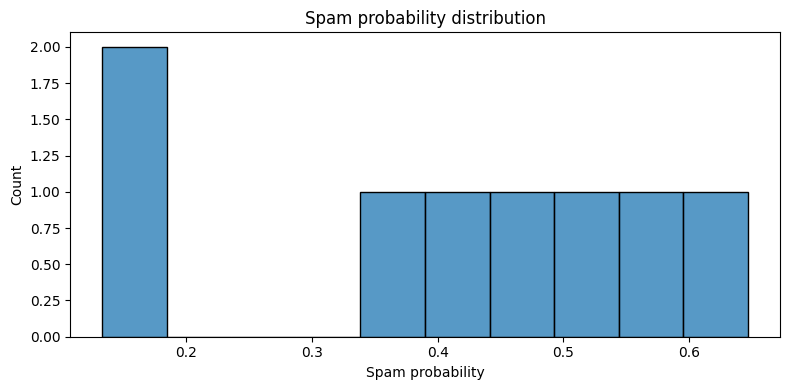

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(preds['spam_probability'], bins=10)
plt.title('Spam probability distribution')
plt.xlabel('Spam probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Confusion matrix

In [9]:
confusion_data = (
    preds.groupby(['actual_label', 'predicted_label'])
    .size()
    .reset_index(name='count')
)
confusion_data

,actual_label,predicted_label,count
0,ham,ham,4
1,spam,ham,1
2,spam,spam,3


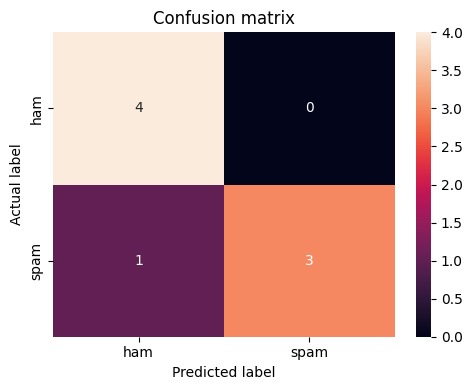

In [10]:
confusion_pivot = confusion_data.pivot(index='actual_label', columns='predicted_label', values='count').fillna(0)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_pivot, annot=True, fmt='.0f')
plt.title('Confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()
plt.show()

## Power BI export

The following files are exported to `outputs/powerbi/`.

In [11]:
metrics_sorted.to_csv(POWERBI_DIR / 'model_metrics_powerbi.csv', index=False)
preds.to_csv(POWERBI_DIR / 'test_predictions_powerbi.csv', index=False)
summary.to_csv(POWERBI_DIR / 'summary_powerbi.csv', index=False)
error_counts.to_csv(POWERBI_DIR / 'error_counts_powerbi.csv', index=False)
confusion_data.to_csv(POWERBI_DIR / 'confusion_matrix_powerbi.csv', index=False)

print('Exported Power BI files:')
for file in POWERBI_DIR.glob('*.csv'):
    print(file)

Exported Power BI files:
outputs\powerbi\confusion_matrix_powerbi.csv
outputs\powerbi\error_counts_powerbi.csv
outputs\powerbi\model_metrics_powerbi.csv
outputs\powerbi\summary_powerbi.csv
outputs\powerbi\test_predictions_powerbi.csv
